# Імітаційна модель задачі планування робочого часу
Побудувати імітаційну модель задачі:
Два доктора має у сумісній власності кабінет, в якому починаючи з 9.00 ведуть ранковий прийом хворих.
Приймальна відкривається в 8.30 та зачиняється в 10.00 ранку.
Секретар зберігає записи про звернення пацієнтів за останні десять тижнів. Крім того,
лікарі також ведуть облік пацієнтів, які прийняті ними у часи консультацій.
При регістрації утворюється дві різні черги до двох лікарів.
Якщо вільний другий лікар, тоді 90% пацієнтів висловлює бажання звернутися до нього, коли підійшла їх черга, а їх лікар зайнятий.
Використовуючи імітаційну модель, оцінити вхідний потік пацієнтів в години ранкового прийому.
- Яка кількість очікує в приймальній в 9.00 ранку?
- Чому дорівнює середній час очікування прийому пацієнтами в черзі?
- В якому часі кожного з лікарів залишає останній пацієнт?

In [74]:
import matplotlib.pyplot as plt
import numpy as np

In [88]:
class Patient:
    def __init__(self, arrival_time: float):
        """
        Represents a patient.

        :param arrival_time: Time when the patient arrives at the clinic.
        """
        self.arrival_time = arrival_time
        self.service_start_time = None
        self.service_end_time = None

    def wait_time(self) -> float:
        if self.service_start_time is not None:
            return (self.service_start_time - self.arrival_time) * 60
        return 0


class Doctor:
    def __init__(self, doctor_id: int):
        """
        Represents a doctor.

        :param doctor_id: Unique identifier for the doctor.
        """
        self.doctor_id = doctor_id
        self.current_patient = None
        self.busy_until = 0
        self.patient_log = []

    def is_free(self, current_time: float) -> bool:
        return current_time >= self.busy_until

    def start_service(self, patient: Patient, current_time: float, service_time: float):
        self.current_patient = patient
        patient.service_start_time = current_time
        patient.service_end_time = current_time + service_time
        self.busy_until = current_time + service_time
        self.patient_log.append(patient)


class Clinic:
    def __init__(self, num_doctors: int, opening_time: float, closing_time: float):
        """
        Represents the clinic.

        :param num_doctors: Number of doctors in the clinic.
        :param opening_time: Opening time of the clinic in hours (e.g., 8.5 for 8:30 AM).
        :param closing_time: Closing time of the clinic in hours (e.g., 10.0 for 10:00 AM).
        """
        self.doctors = [Doctor(i) for i in range(num_doctors)]
        self.opening_time = opening_time
        self.closing_time = closing_time
        self.patients = []
        self.queues: dict[int, list[Patient]] = {i: [] for i in range(num_doctors)}

    def generate_patients(self, arrival_rate: float):
        time = self.opening_time
        while time < self.closing_time:
            interarrival_time = np.random.exponential(1 / arrival_rate)
            time += interarrival_time
            if time < self.closing_time:
                self.patients.append(Patient(time))

    def assign_patient(self, patient: Patient, current_time: float):
        free_doctors = [doctor for doctor in self.doctors if doctor.is_free(current_time)]

        if free_doctors:
            free_doctors[0].start_service(patient, current_time, self.generate_service_time())
        else:
            queue_lengths = {i: len(queue) for i, queue in self.queues.items()}
            primary_doctor = np.argmin(list(queue_lengths.values()))

            if np.random.random() <= 0.9:
                secondary_doctor = (primary_doctor + 1) % len(self.doctors)
                if len(self.queues[secondary_doctor]) < len(self.queues[primary_doctor]):
                    primary_doctor = secondary_doctor

            self.queues[primary_doctor].append(patient)

    def process_queues(self, current_time: float):
        for i, queue in self.queues.items():
            if queue and self.doctors[i].is_free(current_time):
                patient = queue.pop(0)
                self.doctors[i].start_service(patient, current_time, self.generate_service_time())

    @staticmethod
    def generate_service_time() -> float:
        return np.random.uniform(0.1, 0.5)

    def simulate(self):
        current_time = self.opening_time

        for patient in self.patients:
            current_time = patient.arrival_time
            self.assign_patient(patient, current_time)
            self.process_queues(current_time)

        while current_time < self.closing_time:
            current_time += 0.01
            self.process_queues(current_time)

    def calculate_statistics(self):
        total_wait_time = sum(patient.wait_time() for patient in self.patients)
        total_patients = len(self.patients)
        patients_at_nine_am = sum(1 for patient in self.patients if patient.arrival_time < 9.0)
        print(f"Total patients: {total_patients}")
        print(f"Patients waiting at 9:00 AM: {patients_at_nine_am}")
        print(f"Average wait time: {total_wait_time / total_patients if total_patients > 0 else 0:.3f} min")

    def plot_statistics(self):
        arrival_times = [patient.arrival_time for patient in self.patients]
        service_start_times = [patient.service_start_time for patient in self.patients if patient.service_start_time is not None]

        plt.figure(figsize=(12, 6))

        plt.hist(arrival_times, bins=20, alpha=0.7, label="Arrival Times")
        plt.hist(service_start_times, bins=20, alpha=0.7, label="Service Start Times")

        plt.title("Distribution of Arrival and Service Start Times")
        plt.xlabel("Time (hours)")
        plt.ylabel("Number of Patients")
        plt.legend()
        plt.grid()
        plt.show()

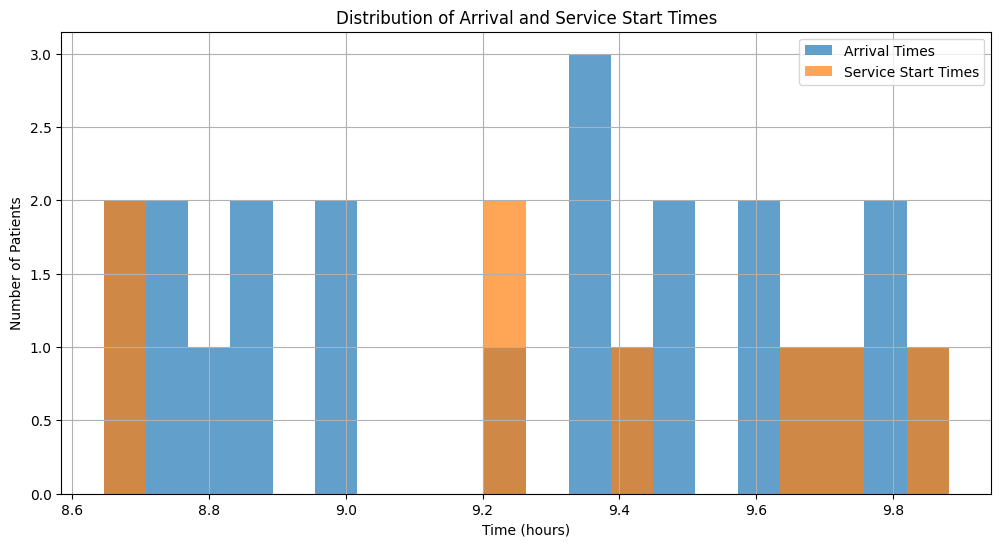

Total patients: 23
Patients waiting at 9:00 AM: 8
Average wait time: 1.229 min


In [90]:
clinic = Clinic(num_doctors=2, opening_time=8.5, closing_time=10.0)
clinic.generate_patients(arrival_rate=15)
clinic.simulate()
clinic.plot_statistics()
clinic.calculate_statistics()